Importing Data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import random

In [3]:
fashion_train_df = pd.read_csv("input/fashion-mnist_train.csv", sep = ",")

In [4]:
fashion_test_df = pd.read_csv("input/fashion-mnist_train.csv", sep = ",")

Vizulazation

In [5]:
fashion_train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
fashion_train_df.tail()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59999,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
fashion_test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
fashion_test_df.tail()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59999,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
fashion_train_df.shape

(60000, 785)

In [10]:
fashion_test_df.shape

(60000, 785)

In [11]:
training = np.array(fashion_train_df, dtype= "float32")

In [12]:
training = np.array(fashion_test_df, dtype= "float32")

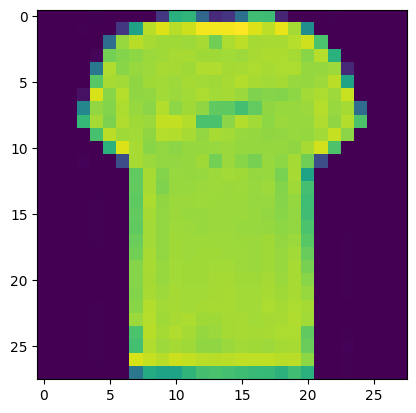

In [13]:
plt.imshow(training[10, 1:].reshape(28, 28))

np.float32(6.0)

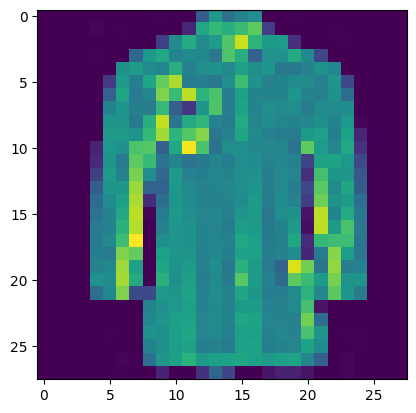

In [14]:
i = random.randint(1,60000)
plt.imshow(training[i, 1:].reshape(28, 28))
label = training[i, 0]
label

In [15]:
# Remember the 10 classes decoding is as follows:
# 0 - T-shirt/top
# 1 - Trouser
# 2 - Pullover
# 3 - Dress
# 4 - Coat
# 5 - Sandal
# 6 - Shirt
# 7 - Sneaker
# 8 - Bag
# 9 - Ankle boot


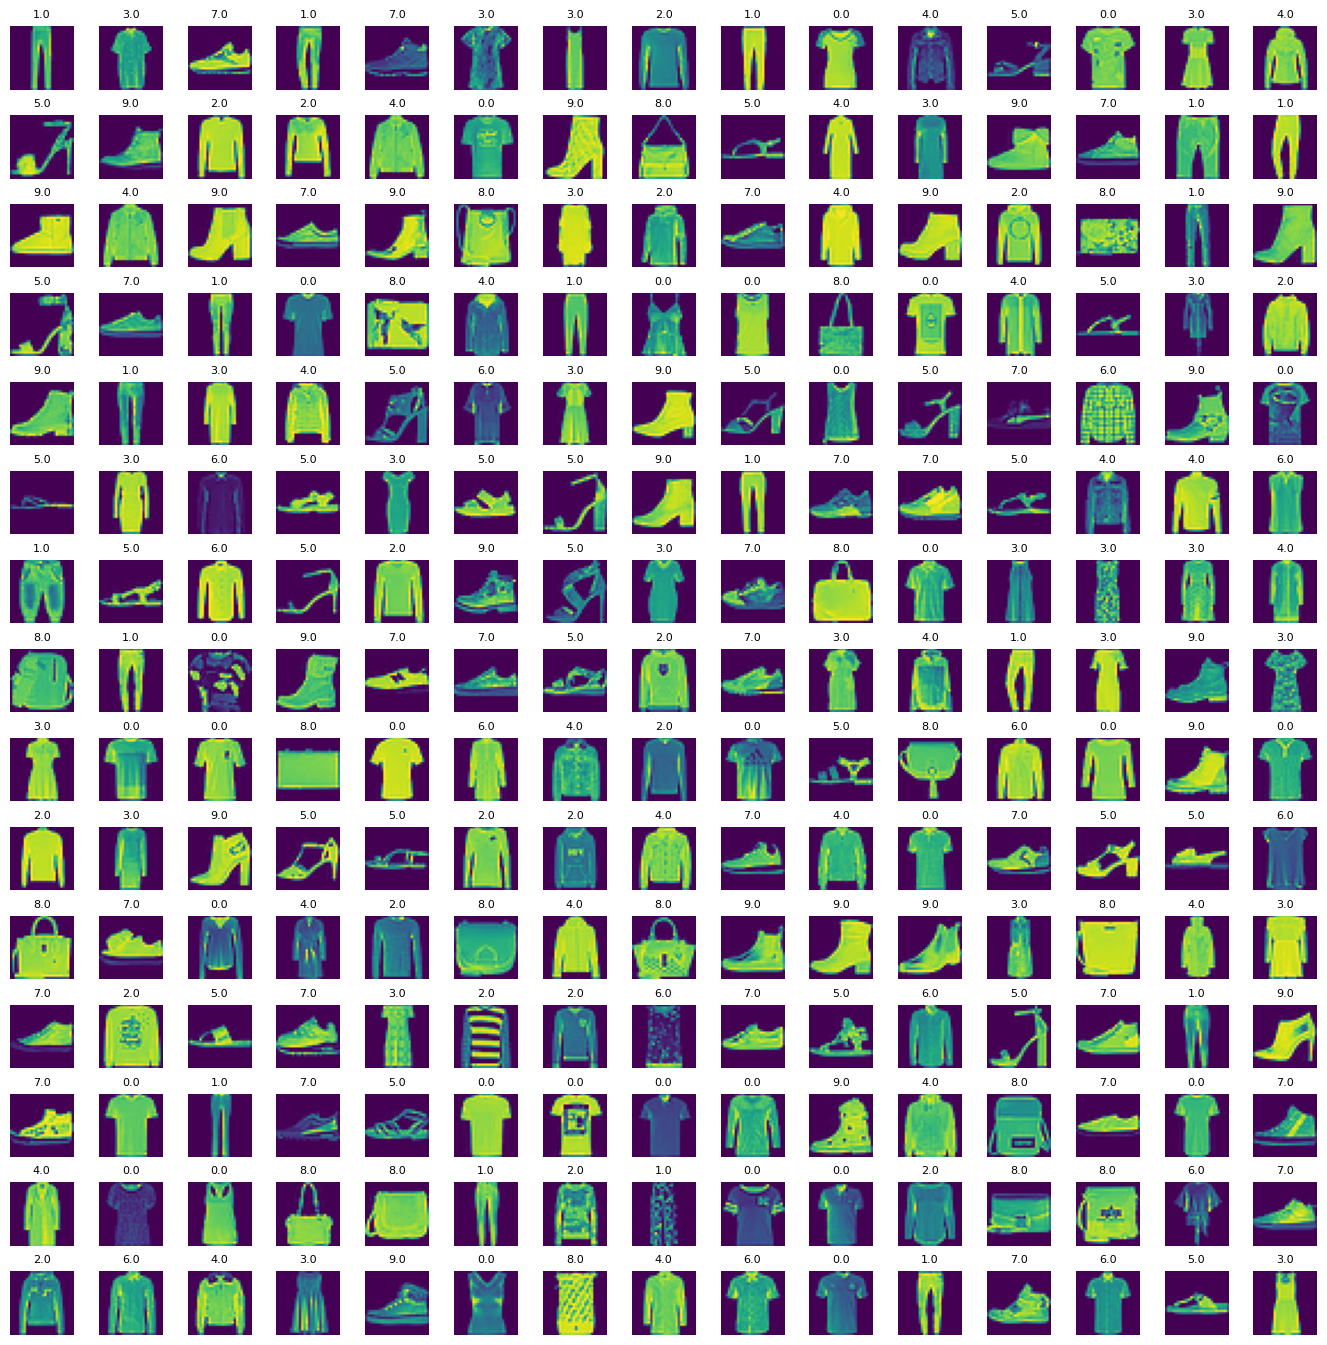

In [16]:
# Let's view more images in a grid format
# Define the dimensions of the plot grid
W_grid = 15
L_grid = 15

# fig, axes = plt.subplots(L_grid, W_grid)
# subplot return the figure object and axes object
# we can use the axes object to plot specific figures at various locations

fig, axes = plt.subplots(L_grid, W_grid, figsize = (17,17))

axes = axes.ravel()  # flatten the 15 x 15 matrix into 225 array

n_training = len(training)  # get the length of the training dataset

# Select a random number from 0 to n_training
for i in np.arange(0, W_grid * L_grid):  # create evenly spaces variables
    
    # Select a random number
    index = np.random.randint(0, n_training)
    
    # read and display an image with the selected index
    axes[i].imshow(training[index,1:].reshape(28,28))
    axes[i].set_title(training[index,0], fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace = 0.4)

Model Training

In [17]:
X_train = training[:, 1:]/255
y_train = training[:, 0]

In [18]:
testing = np.array(fashion_test_df, dtype="float32")

X_test = testing[:, 1:]/255
y_test = testing[:, 0]

In [19]:
%pip install scikit-learn

from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.


In [20]:
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size=0.33, random_state=12345)

In [21]:
X_train = X_train.reshape(X_train.shape[0], *(28,28,1))
X_test = X_test.reshape(X_test.shape[0], *(28,28,1))
X_validate = X_validate.reshape(X_validate.shape[0], *(28,28,1))


In [22]:
X_train.shape

(40200, 28, 28, 1)

In [23]:
X_test.shape

(60000, 28, 28, 1)

In [24]:
X_validate.shape

(19800, 28, 28, 1)

In [25]:
import keras

In [26]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

In [27]:
cnn_model = Sequential()

In [28]:
cnn_model.add(Conv2D(32,3,3, input_shape = (28,28,1), activation = 'relu'))

c:\Users\ASHUTOSH SAHU\OneDrive\Desktop\FashionClass\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
cnn_model.add(MaxPooling2D(pool_size = (2,2)))

In [30]:
cnn_model.add(Flatten())

In [31]:
cnn_model.add(Dense(units=32, activation='relu'))

In [32]:
cnn_model.add(Dense(units = 10, activation='sigmoid'))

In [33]:
cnn_model.compile(loss = 'sparse_categorical_crossentropy', optimizer = Adam(), metrics = ['accuracy'])

In [34]:
epochs = 50

In [35]:
cnn_model.fit(X_train, y_train, batch_size = 512, epochs = epochs, validation_data = (X_validate, y_validate))

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5208 - loss: 1.4756 - val_accuracy: 0.7040 - val_loss: 0.8535
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7262 - loss: 0.7534 - val_accuracy: 0.7440 - val_loss: 0.6934
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7593 - loss: 0.6515 - val_accuracy: 0.7697 - val_loss: 0.6262
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7795 - loss: 0.6014 - val_accuracy: 0.7812 - val_loss: 0.5955
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7900 - loss: 0.5715 - val_accuracy: 0.7917 - val_loss: 0.5649
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8006 - loss: 0.5457 - val_accuracy: 0.8038 - val_loss: 0.5414
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8082 - loss: 0.5257 - val_accuracy: 0.8054 - val_loss: 0.5264
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8135 - loss: 0.5099 - val_accuracy: 0.8112 - val_loss:

Evaluating The Model

In [36]:
evaluation = cnn_model.evaluate(X_test, y_test)
print('Test Accuracy : {:.3f}'.format(evaluation[1]))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 953us/step - accuracy: 0.8701 - loss: 0.3537
Test Accuracy : 0.870


In [37]:
predicted_classes = cnn_model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step


In [38]:
predicted_classes

array([[3.8113350e-01, 1.4859430e-03, 5.9290284e-01, ..., 7.5011944e-06,
        4.2608422e-01, 1.8256822e-05],
       [4.8405639e-04, 4.4861893e-04, 6.8400615e-05, ..., 9.9532330e-01,
        6.9699258e-02, 9.9894011e-01],
       [1.8520894e-02, 5.4376810e-03, 7.0805252e-01, ..., 1.8717343e-07,
        6.1990578e-02, 1.3703111e-07],
       ...,
       [1.3519041e-03, 1.0097614e-04, 4.1179843e-03, ..., 6.2764075e-04,
        9.9476773e-01, 1.3017415e-05],
       [2.1927448e-02, 1.5896162e-03, 5.7086177e-02, ..., 7.1858161e-04,
        9.9676377e-01, 1.2373202e-04],
       [1.0536225e-03, 3.7381433e-02, 1.1064272e-04, ..., 9.9686688e-01,
        3.3388332e-01, 9.0980165e-02]], shape=(60000, 10), dtype=float32)

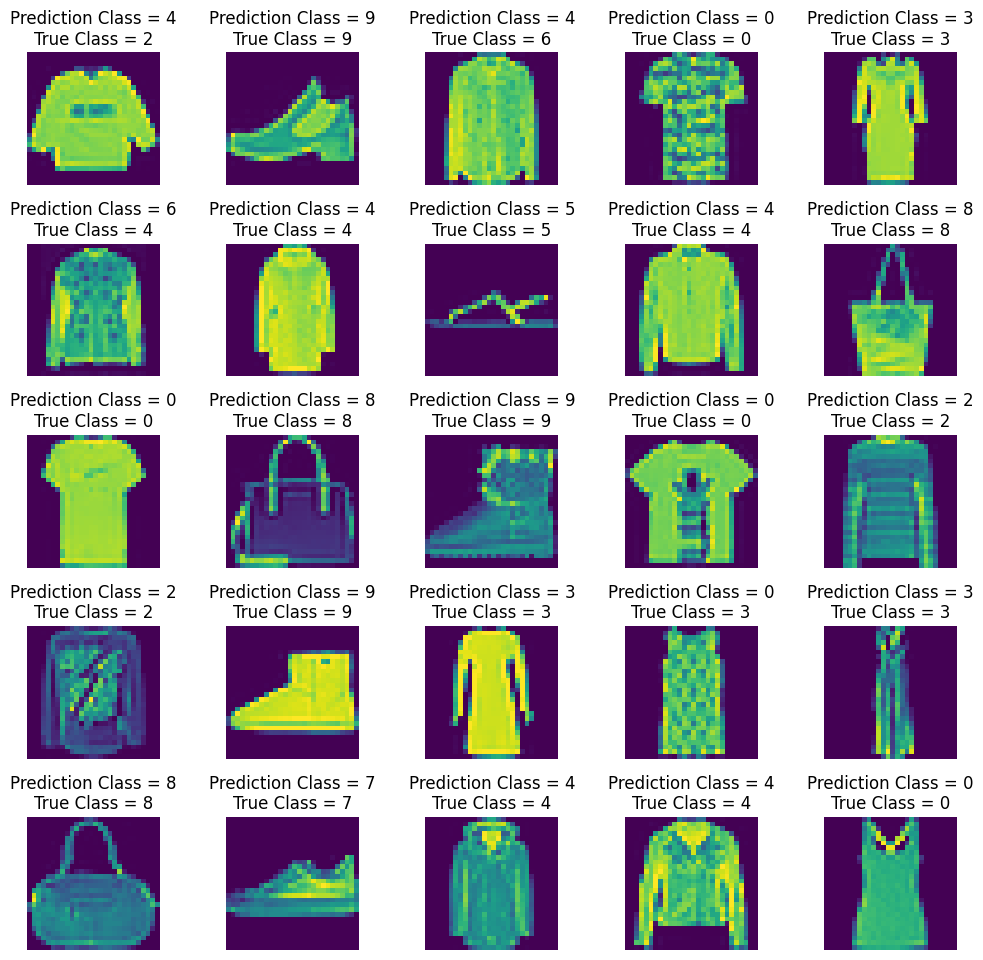

In [39]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(X_test[i].reshape(28,28))
    predicted_label = np.argmax(predicted_classes[i])
    axes[i].set_title(f"Prediction Class = {predicted_label}\nTrue Class = {int(y_test[i])}")
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

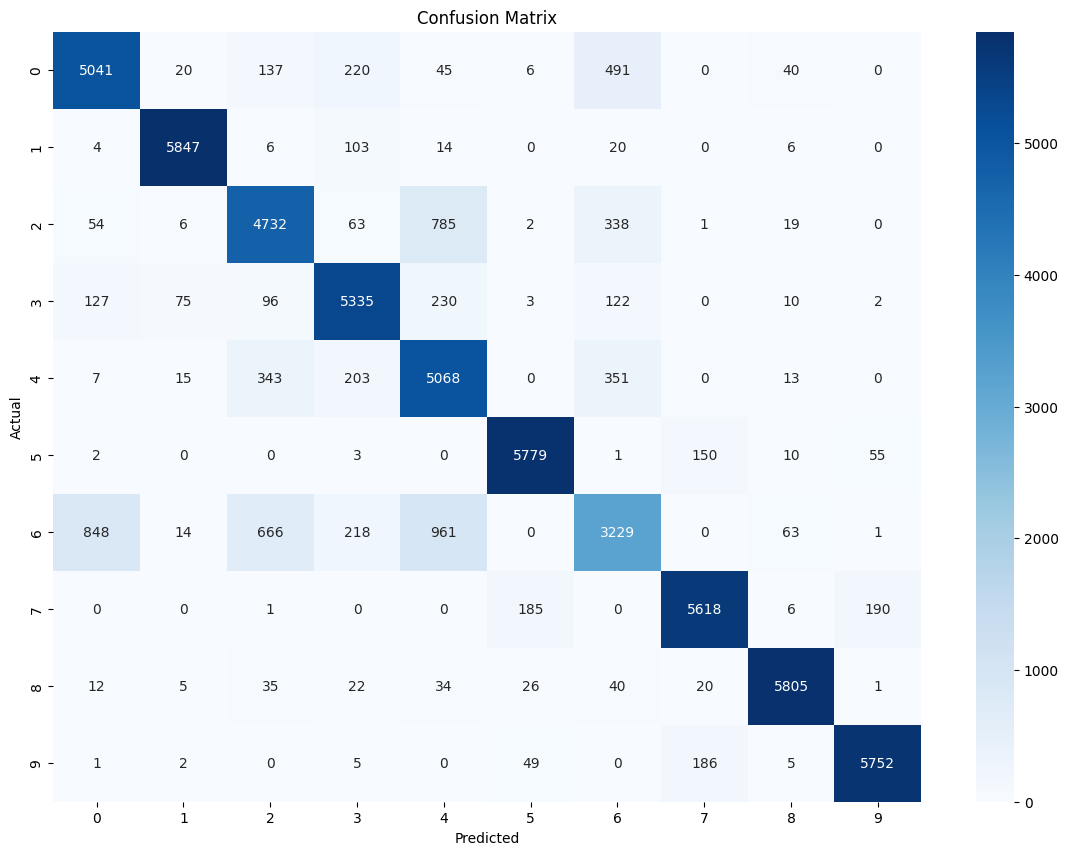

In [43]:
from sklearn.metrics import confusion_matrix

# Convert predictions to class labels
predicted_labels = np.argmax(predicted_classes, axis=1)

# If y_test is one-hot encoded → convert it too
if len(y_test.shape) > 1:
    y_test = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

# Plot
plt.figure(figsize=(14,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [44]:
from sklearn.metrics import classification_report

In [45]:
num_classes = 10 
target_name = ["class {}". format(i) for i in range(num_classes)]
print(classification_report(y_test, predicted_labels, target_names = target_name))

              precision    recall  f1-score   support

     class 0       0.83      0.84      0.83      6000
     class 1       0.98      0.97      0.98      6000
     class 2       0.79      0.79      0.79      6000
     class 3       0.86      0.89      0.88      6000
     class 4       0.71      0.84      0.77      6000
     class 5       0.96      0.96      0.96      6000
     class 6       0.70      0.54      0.61      6000
     class 7       0.94      0.94      0.94      6000
     class 8       0.97      0.97      0.97      6000
     class 9       0.96      0.96      0.96      6000

    accuracy                           0.87     60000
   macro avg       0.87      0.87      0.87     60000
weighted avg       0.87      0.87      0.87     60000

